In [31]:
import pandas as pd

df = pd.read_csv('../data/zameen-updated.csv')
df.shape

(168446, 20)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  str    
 3   property_type  168446 non-null  str    
 4   price          168446 non-null  int64  
 5   location       168446 non-null  str    
 6   city           168446 non-null  str    
 7   province_name  168446 non-null  str    
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  str    
 12  purpose        168446 non-null  str    
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  str    
 15  agency         124375 non-null  str    
 16  agent          124374 non-null  str    
 17  Area Type      168446 non-null  str    


In [33]:
df[['area', 'Area Type', 'Area Size', 'Area Category', 'price', 'purpose', 'property_type']].head(10)

,area,Area Type,Area Size,Area Category,price,purpose,property_type
0,4 Marla,Marla,4.0,0-5 Marla,10000000,For Sale,Flat
1,5.6 Marla,Marla,5.6,5-10 Marla,6900000,For Sale,Flat
2,8 Marla,Marla,8.0,5-10 Marla,16500000,For Sale,House
3,2 Kanal,Kanal,2.0,1-5 Kanal,43500000,For Sale,House
4,8 Marla,Marla,8.0,5-10 Marla,7000000,For Sale,House
5,1.6 Kanal,Kanal,1.6,1-5 Kanal,34500000,For Sale,House
6,1 Kanal,Kanal,1.0,1-5 Kanal,27000000,For Sale,House
7,6.2 Marla,Marla,6.2,5-10 Marla,7800000,For Sale,Flat
8,1 Kanal,Kanal,1.0,1-5 Kanal,50000000,For Sale,House
9,1 Kanal,Kanal,1.0,1-5 Kanal,40000000,For Sale,Penthouse


In [34]:
df['purpose'].value_counts()

purpose
For Sale    120655
For Rent     47791
Name: count, dtype: int64

In [35]:
df['property_type'].value_counts()

property_type
House            105468
Flat              38238
Upper Portion     13774
Lower Portion      9229
Room                685
Farm House          657
Penthouse           395
Name: count, dtype: int64

In [36]:
df_sale = df[df['purpose'] == 'For Sale'].copy()
df_sale.shape

(120655, 20)

In [37]:
df_sale['Area Type'].value_counts()

Area Type
Marla    102158
Kanal     18497
Name: count, dtype: int64

In [38]:
df_sale['area_marla'] = df_sale.apply(
    lambda row: row['Area Size'] * 20 if row['Area Type'] == 'Kanal' else row['Area Size'],
    axis=1
)

In [39]:
df_sale[['area', 'Area Type', 'Area Size', 'area_marla']].head(10)

,area,Area Type,Area Size,area_marla
0,4 Marla,Marla,4.0,4.0
1,5.6 Marla,Marla,5.6,5.6
2,8 Marla,Marla,8.0,8.0
3,2 Kanal,Kanal,2.0,40.0
4,8 Marla,Marla,8.0,8.0
5,1.6 Kanal,Kanal,1.6,32.0
6,1 Kanal,Kanal,1.0,20.0
7,6.2 Marla,Marla,6.2,6.2
8,1 Kanal,Kanal,1.0,20.0
9,1 Kanal,Kanal,1.0,20.0


In [40]:
df_sale = df_sale.drop(columns=['area', 'Area Type', 'Area Size', 'Area Category'])
df_sale.columns.tolist()

['property_id',
 'location_id',
 'page_url',
 'property_type',
 'price',
 'location',
 'city',
 'province_name',
 'latitude',
 'longitude',
 'baths',
 'purpose',
 'bedrooms',
 'date_added',
 'agency',
 'agent',
 'area_marla']

In [41]:
df_sale[['price', 'area_marla']].describe()

,price,area_marla
count,1.206550e+05,120655.000000
mean,2.476513e+07,11.065215
std,3.959754e+07,59.560442
min,0.000000e+00,0.000000
25%,7.400000e+06,4.800000
50%,1.350000e+07,6.400000
75%,2.600000e+07,10.000000
max,2.000000e+09,12000.000000


In [42]:
df_sale[df_sale['price'] == 0].shape

(2, 17)

In [43]:
df_sale.nlargest(10, 'price')[['price', 'area_marla', 'city', 'property_type', 'location']]

,price,area_marla,city,property_type,location
85499,2000000000,384.0,Lahore,House,Mall Road
58032,1450000000,122.0,Karachi,House,KDA Scheme 1
68867,1430000000,260.0,Lahore,House,Gulberg
77087,1350000000,120.0,Karachi,House,KDA Scheme 1
15320,1270000000,128.0,Lahore,House,Gulberg
84,1250000000,160.0,Lahore,House,Gulberg
74283,1250000000,160.0,Lahore,House,Gulberg
312,1200000000,160.0,Lahore,House,Gulberg
55589,1000000000,80.0,Karachi,House,Clifton
95572,1000000000,180.0,Lahore,House,Gulberg


In [44]:
df_sale.nlargest(10, 'area_marla')[['price', 'area_marla', 'city', 'property_type', 'location']]

,price,area_marla,city,property_type,location
68989,2200000,12000.0,Karachi,Lower Portion,Qayyumabad
7711,884000000,8320.0,Lahore,Farm House,Jaranwala Road
74447,450000000,6000.0,Islamabad,Farm House,Simly Dam Road
129041,450000000,6000.0,Islamabad,Farm House,Simly Dam Road
151417,80000000,5100.0,Lahore,Farm House,Cantt
43783,300000000,3360.0,Islamabad,Farm House,Tumair
45173,300000000,3360.0,Islamabad,Farm House,Chirah
149501,15000000,2302.0,Islamabad,Flat,Gulshan-e-Khudadad
4891,350000000,2000.0,Islamabad,Farm House,H-9
103979,200000000,2000.0,Lahore,Farm House,Multan Road


In [45]:
# Drop zero-price listings
df_sale = df_sale[df_sale['price'] > 0]

# Drop the clear area error (Lower Portion at 12000 Marla)
df_sale = df_sale[df_sale['area_marla'] < 12000]

df_sale.shape

(120652, 17)

In [46]:
df_sale['date_added'] = pd.to_datetime(df_sale['date_added'])
df_sale['date_added'].min(), df_sale['date_added'].max()

(Timestamp('2018-08-05 00:00:00'), Timestamp('2019-07-18 00:00:00'))

In [47]:
df_sale['agency'].nunique()

5501

In [48]:
df_sale = df_sale.drop(columns=[
    'property_id', 'location_id', 'page_url', 
    'agency', 'agent', 'date_added', 'purpose'
])
df_sale.columns.tolist()

['property_type',
 'price',
 'location',
 'city',
 'province_name',
 'latitude',
 'longitude',
 'baths',
 'bedrooms',
 'area_marla']

In [49]:
for col in ['property_type', 'location', 'city', 'province_name']:
    print(col, '->', df_sale[col].nunique())

property_type -> 7
location -> 1455
city -> 5
province_name -> 3


In [50]:
df_sale = df_sale.drop(columns=['location'])
df_sale.columns.tolist()

['property_type',
 'price',
 'city',
 'province_name',
 'latitude',
 'longitude',
 'baths',
 'bedrooms',
 'area_marla']

In [51]:
from sklearn.model_selection import train_test_split

X = df_sale.drop(columns=['price'])
y = df_sale['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((96521, 8), (24131, 8))

In [52]:
X_train_encoded = pd.get_dummies(X_train, columns=['property_type', 'city', 'province_name'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['property_type', 'city', 'province_name'], drop_first=True)

X_train_encoded.shape, X_test_encoded.shape

((96521, 17), (24131, 17))

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_encoded, y_train)

y_pred = lr.predict(X_test_encoded)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.0f}")
print(f"R²: {r2:.4f}")

MAE: 16,931,230
R²: 0.1672


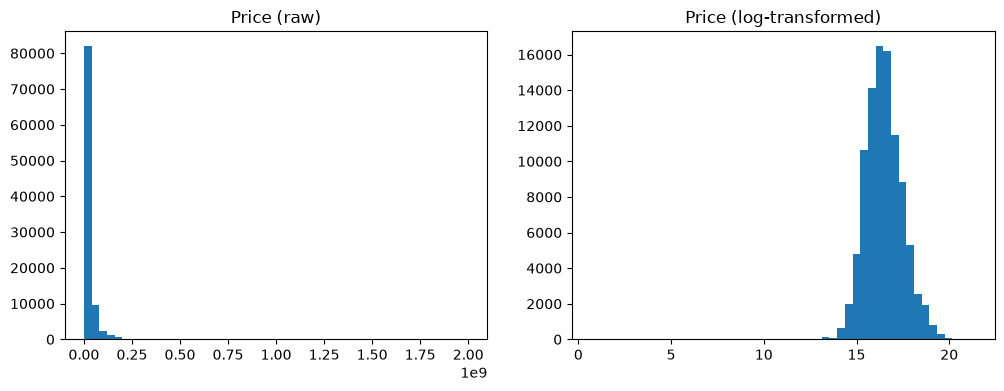

In [54]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=50)
axes[0].set_title('Price (raw)')

axes[1].hist(np.log1p(y_train), bins=50)
axes[1].set_title('Price (log-transformed)')
plt.show()

In [55]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr = LinearRegression()
lr.fit(X_train_encoded, y_train_log)

y_pred_log = lr.predict(X_test_encoded)

# Convert predictions back to actual PKR for interpretable MAE
y_pred_actual = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test, y_pred_actual)
r2 = r2_score(y_test_log, y_pred_log)

print(f"MAE (PKR): {mae:,.0f}")
print(f"R² (log scale): {r2:.4f}")

MAE (PKR): 624,090,545,581
R² (log scale): 0.3374


In [56]:
results = pd.DataFrame({
    'y_test_actual': y_test.values,
    'y_pred_log': y_pred_log,
    'y_pred_actual': y_pred_actual
})
results.nlargest(5, 'y_pred_actual')

,y_test_actual,y_pred_log,y_pred_actual
1674,450000000,36.557498,7.528691e+15
17664,450000000,36.557498,7.528691e+15
7533,300000000,28.415445,2.191143e+12
9964,360000000,22.164317,4.225136e+09
16793,11500000,22.148855,4.160310e+09


In [57]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train_encoded, y_train_log)

y_pred_log_xgb = xgb_model.predict(X_test_encoded)
y_pred_actual_xgb = np.expm1(y_pred_log_xgb)

mae_xgb = mean_absolute_error(y_test, y_pred_actual_xgb)
r2_xgb = r2_score(y_test_log, y_pred_log_xgb)

print(f"MAE (PKR): {mae_xgb:,.0f}")
print(f"R² (log scale): {r2_xgb:.4f}")

MAE (PKR): 4,824,116
R² (log scale): 0.8854


In [58]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train_encoded.columns)
importances.sort_values(ascending=False).head(10)

area_marla                     0.524547
property_type_House            0.100898
bedrooms                       0.056336
city_Rawalpindi                0.050473
latitude                       0.042850
property_type_Lower Portion    0.039207
property_type_Upper Portion    0.037300
property_type_Flat             0.035270
longitude                      0.023091
property_type_Room             0.021554
dtype: float32

In [59]:
import joblib

# Save the trained model
joblib.dump(xgb_model, '../models/house_price_model.pkl')

# Save the column structure the model expects
model_columns = X_train_encoded.columns.tolist()
joblib.dump(model_columns, '../models/model_columns.pkl')

print("Model and columns saved.")
print(f"Number of columns: {len(model_columns)}")

Model and columns saved.
Number of columns: 17
